# Data Visualization

***Course:*** 2026SPW MGS3001 WHS01 — Python Programming for Business  
***Date & Time:*** 19 May 2026, 10:00 – 11:15  
***Venue:*** CBPM A102, Wenzhou-Kean University  
***Instructor:*** Dawei Chen

### Learning Objectives

1. **Understand** what data visualization is and why it is essential for research
2. **Distinguish** good visualizations from bad ones using design principles
3. **Choose** the right chart type for different data and analytical questions
4. **Create** publication-quality figures in Python using matplotlib and seaborn
5. **Use AI** to assist with visualization code while <span style="color:red">maintaining design judgmen</span>

### Where Does Visualization Fit?

`Collect ✓ → Clean ✓ → Transform ✓ → EDA ✓ →` <span style="color:blue">**Visualize (TODAY)**</span> → Model (5/21 & 26) → Report (5/28)

In the EDA session, we generated quick exploratory plots to **understand** the data for ourselves.

Today, we create **polished, publication-quality** figures designed to **communicate findings to others** — readers of your paper and your presentation audience.

---
## 1. What Is Data Visualization?

**Data visualization** is the graphical representation of information and data. It uses visual elements — **charts, graphs, tables, maps** — to <span style="color:red">make patterns, trends, and outliers in data accessible and understandable</span>.

### 1.1. Why It Matters

| Purpose | What It Does | Example |
|---|---|---|
| **Simplifies complexity** | Makes large datasets understandable at a glance | A histogram shows 37 repos' star distribution in one image |
| **Reveals patterns** | Surfaces relationships, anomalies, outliers | A scatter plot reveals that topic count predicts stars |
| **Communicates to non-experts** | Shares insights with managers, reviewers, public | A clear bar chart replaces a paragraph of numbers |
| **Supports decisions** | Visual evidence helps justify analytical choices | Box plots show why you kept the outlier |
| **Engages the audience** | Visuals are more memorable than raw numbers | Your presentation will be 80% figures |

*`Data visualization transforms raw data into clear, compelling insights.`*

### 1.2. Why Visualization? — Anscombe's Quartet (1973)

Four datasets with **identical** summary statistics: same mean of x (9.0) and y (7.5), same standard deviation, same correlation (r = 0.816), and same regression line (y = 3 + 0.5x).

The numbers say they're the same. **But are they?**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean default style for the entire notebook
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

In [2]:
# Anscombe's Quartet data
anscombe = pd.DataFrame({
    'dataset': ['I']*11 + ['II']*11 + ['III']*11 + ['IV']*11,
    'x': [10,8,13,9,11,14,6,4,12,7,5,  10,8,13,9,11,14,6,4,12,7,5,
          10,8,13,9,11,14,6,4,12,7,5,   8,8,8,8,8,8,8,19,8,8,8],
    'y': [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68,
          9.14,8.14,8.74,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74,
          7.46,6.77,12.74,7.11,7.81,8.84,6.08,5.39,8.15,6.42,5.73,
          6.58,5.76,7.71,8.84,8.47,7.04,5.25,12.50,5.56,7.91,6.89]
})

# Verify: identical stats
print("Summary statistics by dataset (all the same!):")
print(anscombe.groupby('dataset').agg(
    x_mean=('x', 'mean'), y_mean=('y', 'mean'),
    x_std=('x', 'std'), y_std=('y', 'std')
).round(2))

Summary statistics by dataset (all the same!):
         x_mean  y_mean  x_std  y_std
dataset                              
I           9.0     7.5   3.32   2.03
II          9.0     7.5   3.32   2.03
III         9.0     7.5   3.32   2.03
IV          9.0     7.5   3.32   2.03


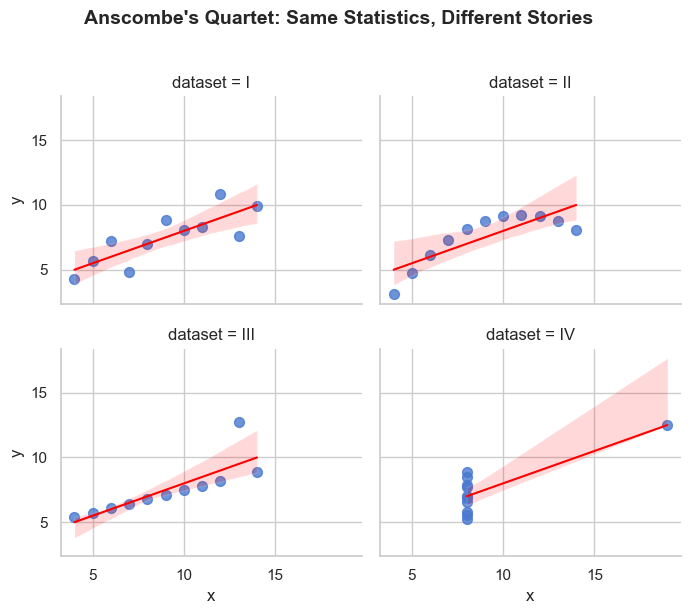

In [3]:
# Plot them — the stories are completely different
g = sns.lmplot(data=anscombe, x="x", y="y", col="dataset",
               col_wrap=2, height=3, aspect=1.2,
               scatter_kws={"s": 50, "alpha": 0.8},
               line_kws={"color": "red", "linewidth": 1.5})
g.figure.suptitle("Anscombe's Quartet: Same Statistics, Different Stories",
                  fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Takeaway:** Numbers alone can hide the truth. Visualization reveals what statistics cannot.

- **Dataset I:** A normal linear relationship ✓
- **Dataset II:** A curved (nonlinear) relationship — the linear model is wrong
- **Dataset III:** A perfect linear trend with one outlier pulling the slope
- **Dataset IV:** No relationship at all — one extreme x-value creates a false correlation

*`"The greatest value of a picture is when it forces us to notice what we never expected to see."`*  — John Tukey (1977)

---
## 2. What Makes a Good vs. Bad Visualization?

### Six Principles of Good Visualization

| # | Principle | What It Means |
|---|---|---|
| 1 | **Know your audience** | Design for their needs and context |
| 2 | **Be accurate & maintain integrity** | Represent data truthfully — avoid misleading scales |
| 3 | **Keep it simple** | Minimize clutter — maximize the data-ink ratio (Tufte, 1983) |
| 4 | **Choose the right chart** | Match chart type to data type and analytical question |
| 5 | **Use design wisely** | Color, size, and shape should emphasize patterns, not decorate |
| 6 | **Tell a story** | The title should state the insight, not just describe the axes |

### Common Pitfalls of Bad Visualization

| ❌ Pitfall | Why It's Bad | ✅ Fix |
|---|---|---|
| **Misleading scales** | Truncated axes exaggerate small differences | Start bar chart y-axis at 0 |
| **3D effects** | Distort perception — hard to read actual values | Always use 2D |
| **Too much clutter** | Heavy gridlines, borders, backgrounds distract | Remove non-data ink (Tufte) |
| **Wrong chart type** | Pie chart for 12 categories is unreadable | Use bar chart instead |
| **Overuse of colors** | Rainbow palette is confusing | Use 2–3 purposeful colors |
| **Cherry-picking** | Showing only a subset to push a narrative | Show all relevant data |
| **Generic title** | "Chart 1" tells the reader nothing | State the finding in the title |

### The Data-Ink Ratio (Edward Tufte, 1983)

$$\text{Data-Ink Ratio} = \frac{\text{Ink used to represent data}}{\text{Total ink used in the chart}}$$

Every visual element should either **show data** or **help the reader interpret data**. If it does neither, **remove it**.

Let's see this in action — the **same chart** built two ways.

In [4]:
# Load our GitHub data
df = pd.read_csv("github_repos_cleaned.csv")
df["log_stars"] = np.log1p(df["stargazers_count"])
print(f"Loaded: {df.shape[0]} repos, {df.shape[1]} columns")

FileNotFoundError: [Errno 2] No such file or directory: 'github_repos_cleaned.csv'

In [ ]:
# ❌ BAD VERSION: cluttered, poor defaults, unnecessary decoration
fig, ax = plt.subplots(figsize=(8, 5))

means = df.groupby("owner_type")["stargazers_count"].mean()
bars = ax.bar(means.index, means.values, color=["red", "blue"],
              edgecolor="black", linewidth=2)
ax.set_title("STARS BY OWNER TYPE!!!!", fontsize=20, color="red")
ax.set_ylabel("Average Stars", fontsize=14)
ax.grid(True, which="both", axis="both", linewidth=1.5)
ax.set_facecolor("lightyellow")
fig.patch.set_facecolor("lightcyan")
for bar in bars:
    ax.annotate(f"{bar.get_height():,.0f}",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=16, fontweight="bold",
                color="red", arrowprops=dict(arrowstyle="->", color="red"))
plt.show()

In [ ]:
# ✅ GOOD VERSION: clean, focused, the title states the insight
fig, ax = plt.subplots(figsize=(7, 4))

colors = ["#64748B", "#3B82F6"]
bars = ax.bar(means.index, means.values, color=colors,
              edgecolor="white", width=0.5)

ax.set_title("Organization-Owned Repos Attract Fewer Stars on Average",
             fontsize=13, fontweight="bold", pad=10)
ax.set_ylabel("Mean Stargazers Count")
ax.set_xlabel("")

# Clean value labels
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f"{bar.get_height():,.0f}", ha="center", fontsize=11, color="#334155")

# Remove top and right spines (Tufte-style)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, means.max() * 1.15)

plt.tight_layout()
plt.show()

**What changed between the bad and good version?**

| Bad Version | Good Version | Principle |
|---|---|---|
| Colored backgrounds | White background | Data-ink ratio |
| ALL-CAPS red title | Title states the *finding* | Tell a story |
| Heavy gridlines on both axes | Minimal — only what aids reading | Keep it simple |
| Red/blue with no meaning | Muted palette — purposeful contrast | Use design wisely |
| Arrow annotations | Clean text labels | Keep it simple |
| All four spines visible | Top & right spines removed | Data-ink ratio |

**Key rule:** The title should state the *insight*, not just name the axes:
- ❌ "Stars by Owner Type"
- ✅ "Organization-Owned Repos Attract Fewer Stars on Average"

### ✅ Quick Check #1 — Critique the Charts

Look at the two charts above and answer:

1. In the bad version, can you name **three specific elements** that violate the data-ink ratio principle?
2. In the good version, why did we remove the top and right spines? Do they carry any data?
3. Why does a title like "Organization-Owned Repos Attract Fewer Stars" work better than "Stars by Owner Type"?

---
## Section 3: How to Visualize Data — Choosing the Right Chart

The right chart depends on your **question** and your **data type**.

| Your Question | Data Type | Chart Type | Seaborn / Matplotlib |
|---|---|---|---|
| What is the **distribution** of a variable? | Numeric | Histogram, KDE, box plot | `sns.histplot()`, `sns.boxplot()` |
| How do **groups compare**? | Numeric + Categorical | Bar chart, box plot, violin | `sns.barplot()`, `sns.boxplot()` |
| What is the **relationship** between two variables? | Numeric + Numeric | Scatter plot | `sns.scatterplot()`, `sns.regplot()` |
| How are **all variables correlated**? | Multiple numeric | Heatmap | `sns.heatmap()` |
| What is the **composition** of categories? | Categorical | Bar chart (horizontal) | `plt.barh()` |

### The Process

1. **Ask:** What question am I answering with this figure?
2. **Choose:** What chart type matches my question and data?
3. **Draft:** Create a basic plot with default settings
4. **Refine:** Add informative title, clean labels, remove clutter
5. **Save:** Export at 300 dpi for your paper

Let's walk through each chart type with our GitHub data.

### 3.1 Distribution: Histogram + KDE

In [ ]:
# Distribution of log(Stars) — the variable we'll use as our DV
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(df["log_stars"], bins=15, kde=True, color="#3B82F6",
             edgecolor="white", alpha=0.7, ax=ax)

# Add mean line
mean_val = df["log_stars"].mean()
ax.axvline(mean_val, color="#DC2626", linestyle="--", linewidth=1.5,
           label=f"Mean = {mean_val:.1f}")

ax.set_title("Distribution of log(Stargazers Count)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("log(Stars + 1)")
ax.set_ylabel("Frequency")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

**Key features:**
- `kde=True` adds a smooth density curve over the histogram — shows the overall shape
- `ax.axvline()` adds a reference line for the mean
- `sns.despine()` removes top and right spines (one line of code for Tufte-style cleanup)

### 3.2 Group Comparison: Box Plot + Strip Plot

In [ ]:
# Compare log(Stars) by owner type
# Box plot shows distribution summary; strip plot shows individual data points
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(data=df, x="owner_type", y="log_stars",
            palette=["#94A3B8", "#3B82F6"], width=0.4,
            linewidth=1.2, ax=ax)
sns.stripplot(data=df, x="owner_type", y="log_stars",
              color="#1E293B", alpha=0.5, size=5, jitter=True, ax=ax)

ax.set_title("Individual Developers Show Higher Variance in Popularity",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Owner Type")
ax.set_ylabel("log(Stars + 1)")
sns.despine()
plt.tight_layout()
plt.show()

**Why box plot + strip plot?** The box shows the summary (median, quartiles, whiskers). The strip shows every individual data point. With a small sample (n = 37), showing actual data points is critical — it prevents the reader from assuming a large sample behind a smooth box.

### 3.3 Relationship: Scatter Plot with Regression Line

In [ ]:
# Relationship between topic count and popularity
fig, ax = plt.subplots(figsize=(8, 5))

sns.regplot(data=df, x="topic_count", y="log_stars",
            scatter_kws={"s": 60, "alpha": 0.7, "edgecolor": "white"},
            line_kws={"color": "#DC2626", "linewidth": 1.5},
            color="#3B82F6", ax=ax)

# Add correlation annotation
r = df[["topic_count", "log_stars"]].corr().iloc[0, 1]
ax.annotate(f"r = {r:.2f}", xy=(0.05, 0.92), xycoords="axes fraction",
            fontsize=12, bbox=dict(facecolor="white", edgecolor="gray",
                                   boxstyle="round,pad=0.3"))

ax.set_title("More Topic Tags Are Associated with Higher Popularity",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Topic Tags")
ax.set_ylabel("log(Stars + 1)")
sns.despine()
plt.tight_layout()
plt.show()

**Design choice:** The correlation coefficient (r) is annotated directly on the plot — the reader doesn't need to look up a separate table. The shaded confidence band around the regression line shows uncertainty.

### 3.4 Correlation: Heatmap

In [ ]:
# Publication-ready correlation heatmap
corr_vars = ["log_stars", "desc_word_count", "topic_count",
             "repo_age_days", "is_org", "is_python", "is_permissive"]
labels = ["log(Stars)", "Desc. Words", "Topic Count",
          "Repo Age", "Is Org.", "Is Python", "Is Permissive"]

corr = df[corr_vars].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Lower triangle only

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            xticklabels=labels, yticklabels=labels,
            cbar_kws={"shrink": 0.8}, ax=ax)

ax.set_title("Pairwise Correlations Among Key Variables",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

**Design choices:**
- `mask=mask` shows only the lower triangle — the upper triangle is redundant (symmetric)
- `cmap="RdBu_r"` is a diverging colormap — red for positive, blue for negative, white for zero
- `center=0` ensures the color midpoint is at zero correlation
- Clean readable labels instead of raw column names

### 3.5 Composition: Horizontal Bar Chart with Highlighting

In [ ]:
# Programming language composition — highlight Python
fig, ax = plt.subplots(figsize=(7, 4))

lang_counts = df["language"].value_counts().head(6)
# Highlight Python, gray out the rest — preattentive processing
colors = ["#3B82F6" if lang == "Python" else "#CBD5E1" for lang in lang_counts.index]

bars = ax.barh(lang_counts.index, lang_counts.values, color=colors, edgecolor="white")
ax.invert_yaxis()

for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.0f}", va="center", fontsize=11, color="#334155")

ax.set_title("Python Dominates the AI Open-Source Ecosystem",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Repositories")
sns.despine()
plt.tight_layout()
plt.show()

**Design choice:** Python is highlighted in blue while other languages are gray. This uses **preattentive processing** — the viewer's eye is drawn to the contrast before they consciously read the chart. Color is used to direct attention to the key finding, not to decorate.

### 💬 Think & Discuss #2

> Look at the five chart types above (histogram, box+strip, scatter, heatmap, bar). For **your own research question**, which chart types would you need? What variable would go on each axis?

Discuss with your neighbor for 2 minutes.

---
## Section 4: Multi-Panel Figures

Academic papers often use **multi-panel figures** — several related plots arranged in a single figure. This saves space and enables direct visual comparison.

In [ ]:
# Multi-panel: compare log(Stars) across all binary group variables
binary_vars = ["is_org", "is_python", "is_permissive", "mentions_ai"]
nice_labels = ["Organization", "Python Language", "Permissive License", "Mentions AI"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, bvar, label in zip(axes, binary_vars, nice_labels):
    sns.boxplot(data=df, x=bvar, y="log_stars",
                palette=["#CBD5E1", "#3B82F6"], width=0.45, ax=ax)
    ax.set_xlabel(label)
    ax.set_xticklabels(["No", "Yes"])
    ax.set_title(label, fontsize=11, fontweight="bold")
    if ax != axes[0]:
        ax.set_ylabel("")
    else:
        ax.set_ylabel("log(Stars + 1)")

fig.suptitle("Figure 2: Popularity by Repository Characteristics",
             fontsize=14, fontweight="bold", y=1.03)
sns.despine()
plt.tight_layout()
plt.show()

**Tips for multi-panel figures:**
- `sharey=True` ensures panels share the same y-axis scale — comparison is fair
- Only label the y-axis on the leftmost panel to reduce clutter
- Add a figure-level title with "Figure X:" numbering for your paper
- Use consistent colors across panels (gray = No, blue = Yes)

### ✅ Quick Check #2 — Design Decisions

Look at the multi-panel figure above and answer:

1. Why is `sharey=True` important? What would happen if each panel had its own y-axis scale?
2. Why did we label the y-axis only on the leftmost panel?
3. Which binary variable shows the largest difference between groups?

---
## Section 5: Saving Figures for Your Paper

To include figures in your Word document or PowerPoint, save them as high-resolution image files.

In [ ]:
# Recreate and SAVE the scatter plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df, x="topic_count", y="log_stars",
            scatter_kws={"s": 60, "alpha": 0.7, "edgecolor": "white"},
            line_kws={"color": "#DC2626", "linewidth": 1.5},
            color="#3B82F6", ax=ax)
r = df[["topic_count", "log_stars"]].corr().iloc[0, 1]
ax.annotate(f"r = {r:.2f}", xy=(0.05, 0.92), xycoords="axes fraction",
            fontsize=12, bbox=dict(facecolor="white", edgecolor="gray",
                                   boxstyle="round,pad=0.3"))
ax.set_title("More Topic Tags Are Associated with Higher Popularity",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Topic Tags")
ax.set_ylabel("log(Stars + 1)")
sns.despine()
plt.tight_layout()

# Save
fig.savefig("fig_topics_vs_stars.png", dpi=300, bbox_inches="tight")
print("✅ Saved: fig_topics_vs_stars.png (300 dpi)")
plt.show()

### Saving Best Practices

| Setting | Value | Why |
|---|---|---|
| `dpi=300` | High resolution | Prevents blurry images when printed or projected |
| `bbox_inches="tight"` | Trim whitespace | No wasted space around the figure |
| `.png` format | For Word / PowerPoint | Widely compatible, good quality |
| `.pdf` format | For LaTeX / archival | Vector format — infinite zoom, no pixelation |
| Descriptive filename | `fig_topics_vs_stars.png` | You'll thank yourself when writing the paper |

---
## Section 6: Using AI for Data Visualization

AI tools (ChatGPT, Claude, etc.) can help you write visualization code — but the **design judgment** must remain yours.

### What AI Can Do Well

- Generate matplotlib/seaborn code for a chart type you describe
- Fix syntax errors in your plotting code
- Suggest color palettes and layout options
- Translate a rough sketch ("I want a bar chart comparing X by Y") into working code

### What YOU Must Own

- **Which chart type to use** — AI may default to pie charts or 3D plots
- **What the title says** — AI doesn't know your research question
- **What to include vs. exclude** — AI may add decorative elements that violate Tufte's principle
- **Whether the chart is accurate** — always verify that the code produces the right numbers

### AI Prompt Templates for Visualization

**1. Generate a chart:**
> "Create a seaborn scatter plot of `topic_count` (x-axis) vs. `log_stars` (y-axis) with a regression line. Use a clean academic style: white background, remove top/right spines, annotate the correlation coefficient on the plot. Title should state the finding."

**2. Improve an existing chart:**
> "Here is my matplotlib code: [paste]. Make it publication-quality: increase font sizes, use `sns.despine()`, improve the color palette, and change the title from descriptive to insight-based."

**3. Create a multi-panel figure:**
> "Create a 1×4 multi-panel box plot comparing `log_stars` across four binary variables: is_org, is_python, is_permissive, mentions_ai. Use shared y-axis, consistent blue/gray colors, and clean labels."

**4. Fix a problem:**
> "My seaborn heatmap labels are overlapping. How do I rotate them and adjust the figure size?"

### 💬 Think & Discuss #3

> You ask AI to create a chart for your paper and it produces a 3D pie chart with a rainbow palette. It looks impressive but violates multiple design principles.
>
> What would you change? Which of the six principles does it violate?

---
## Section 7: Putting It All Together — Figure Checklist

Before including any figure in your paper or presentation, check:

| ✅ Check | Question |
|---|---|
| Chart type | Does the chart match my data type and question? |
| Title | Does the title state the *finding*, not just describe the axes? |
| Axes | Are both axes labeled with descriptive names and units? |
| Clutter | Have I removed unnecessary gridlines, borders, backgrounds? |
| Color | Is color used purposefully (to highlight, not decorate)? |
| Accuracy | Does the y-axis start at 0 (for bar charts)? No misleading scales? |
| Resolution | Saved at 300 dpi with `bbox_inches="tight"`? |
| Numbering | Does it have a figure number (Figure 1, Figure 2, etc.)? |
| Font size | Is all text at least 10pt? Readable when the figure is shrunk to page width? |

---
## 🖥️ Your Turn — Create a Publication-Ready Figure

In the cell below, create **one publication-ready figure** for your project.

Choose from:
1. A scatter plot showing the relationship between your key IV and DV
2. A box plot comparing your DV across groups
3. A bar chart showing composition of a categorical variable

**Requirements:**
- Informative title that states the finding
- Clean axis labels
- `sns.despine()` to remove unnecessary spines
- Save it with `fig.savefig("fig_yourname.png", dpi=300, bbox_inches="tight")`

In [ ]:
# Your publication-ready figure here



---
### 🔄 Session Reflection

Before we wrap up, take 1 minute to reflect:

| Question | Your Answer |
|---|---|
| Which of the six design principles do you think you'll use most? | |
| What's one design mistake you've seen in charts (in papers, news, or presentations) that you now know how to fix? | |
| How many figures do you plan to include in your paper? | |

Share one observation with the class.

---
## What's Next

```
Collect ✓ → Clean ✓ → Transform ✓ → EDA ✓ → Visualize ✓ → Model (5/21 & 26) → Report (5/28)
```

**Wednesday (5/21): Regression Theory** — OLS regression, coefficients, p-values, model specification.

**Your task after class:**
1. Create at least **3 publication-ready figures** for your paper using your own data
2. Save them as `.png` files at 300 dpi
3. For each figure, write a one-sentence caption that states the finding
4. Save this notebook as `05_visualization.ipynb`